# Exploratory Data Analysis (EDA)

## Objective

The objective of the analysis is to explore patient appointments, hospital operations, financial metrics, doctor performance, and patient satisfaction to identify actionable business insights that can support hospital management in improving operational efficiency and patient care.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("healthcare_appointments_cleaned.csv")

In [3]:
df.head()

,patient_id,age,gender,city,bmi,chronic_disease,appointment_type,department,symptoms,severity_level,...,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill,appointment_status,age_group,bmi_category,repeat_patient,long_wait_flag
0,PAT_10000,52,Male,Mumbai,19.6,Hypertension,Scheduled,Neurology,Headache,Low,...,0,8.6,869,413,1936.0,Completed,Middle Aged,Normal,Yes,Yes
1,PAT_10001,21,Female,Mumbai,25.3,No Chronic Disease,Scheduled,Neurology,Headache,Low,...,0,8.8,786,875,1356.6,No Show,Young Adult,Overweight,Yes,Yes
2,PAT_10002,51,Female,Bangalore,21.9,No Chronic Disease,Scheduled,Dermatology,Skin Allergy,Low,...,0,10.0,466,427,1108.8,No Show,Middle Aged,Normal,Yes,Yes
3,PAT_10003,78,Female,Delhi,31.7,No Chronic Disease,Walk-in,Orthopedics,Joint Pain,Low,...,0,8.1,921,401,1417.5,Completed,Senior,Obese,Yes,Yes
4,PAT_10004,62,Female,Mumbai,24.7,Hypertension,Scheduled,Ophthalmology,Eye Irritation,Low,...,0,8.9,152,216,746.9,Completed,Senior,Normal,Yes,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    10000 non-null  str    
 1   age                           10000 non-null  int64  
 2   gender                        10000 non-null  str    
 3   city                          10000 non-null  str    
 4   bmi                           10000 non-null  float64
 5   chronic_disease               10000 non-null  str    
 6   appointment_type              10000 non-null  str    
 7   department                    10000 non-null  str    
 8   symptoms                      10000 non-null  str    
 9   severity_level                10000 non-null  str    
 10  doctor_experience_years       10000 non-null  int64  
 11  consultation_fee              10000 non-null  int64  
 12  insurance                     10000 non-null  str    
 13  appointment_d

# Which age group visit the hospital most frequently

In [5]:
age_group = df["age_group"].value_counts()
age_group

age_group
Senior         3837
Middle Aged    3293
Child          1361
Young Adult     915
Teen            594
Name: count, dtype: int64

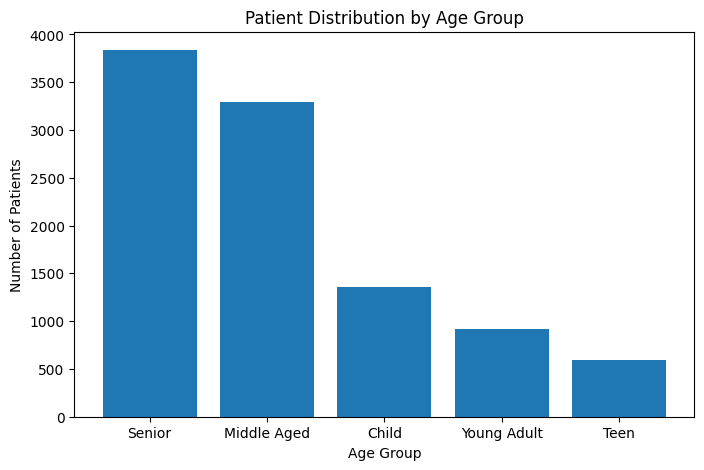

In [104]:
plt.figure(figsize=(8,5))

plt.bar(age_group.index, age_group.values)

plt.title("Patient Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.savefig("age_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

The above distibution of patients based on age_group help to determine that middle aged and senior needs more attention in hospital premises so facilities should be increased in order to get better satisfaction.

# Gender Distribution of patients


In [7]:
gender = df["gender"].value_counts()

gender

gender
Male      5005
Female    4995
Name: count, dtype: int64

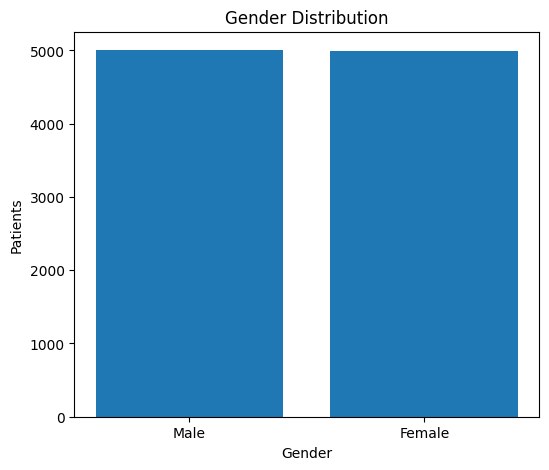

In [105]:
plt.figure(figsize=(6,5))

plt.bar(gender.index, gender.values)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Patients")

plt.savefig("images/02_gender_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

The gender distribution is similar meaning resources are equally utlized 

# Which BMI category is most common

In [9]:
bmi_category = df["bmi_category"].value_counts()

bmi_category

bmi_category
Normal         5213
Overweight     3332
Underweight     843
Obese           612
Name: count, dtype: int64

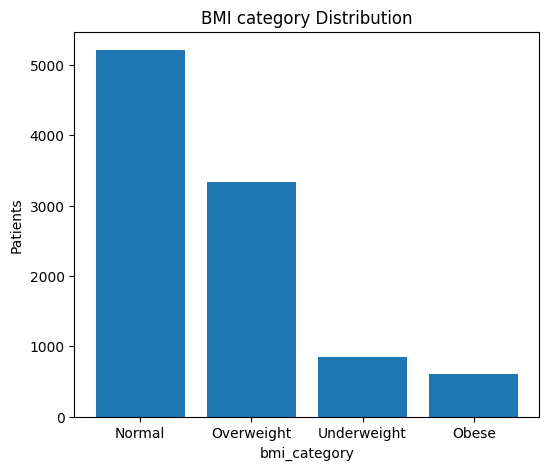

In [10]:
plt.figure(figsize=(6,5))

plt.bar(bmi_category.index, bmi_category.values)

plt.title("BMI category Distribution")

plt.xlabel("bmi_category")

plt.ylabel("Patients")

plt.show()

Most of the patients have normal BMI 

# What percentage of patients have no chronic diseases whereas which chronic disease has what percentage?

In [11]:
df["disease_status"] = np.where(
    df["chronic_disease"] == "No Chronic Disease",
    "No Chronic Disease",
    "Has Chronic Disease"
)

In [12]:
disease_percentage = df["disease_status"].value_counts(normalize=True) * 100

disease_percentage

disease_status
Has Chronic Disease    55.5
No Chronic Disease     44.5
Name: proportion, dtype: float64

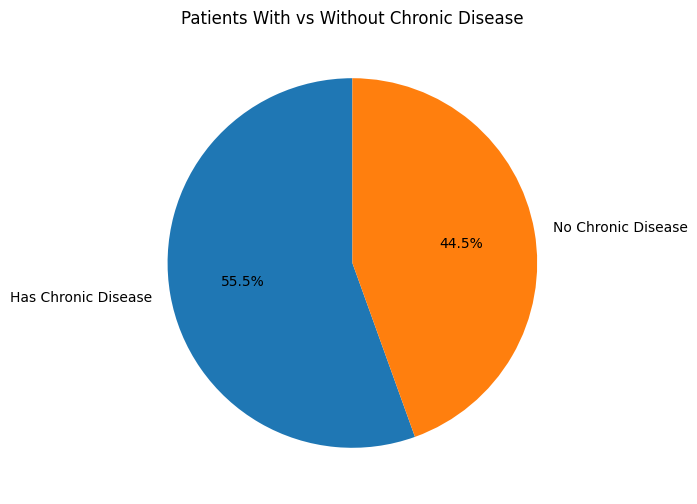

In [106]:
plt.figure(figsize=(6,6))

plt.pie(
    disease_percentage.values,
    labels=disease_percentage.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Patients With vs Without Chronic Disease")

plt.savefig("images/03_Chronic_Disease_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

55% of patients have chronic disease which means there are minimum 55% patients who regularly visit hospital whereas rest 45% are based 

In [14]:
disease_distribution = (
    df[df["chronic_disease"] != "No Chronic Disease"]
    ["chronic_disease"]
    .value_counts()
)

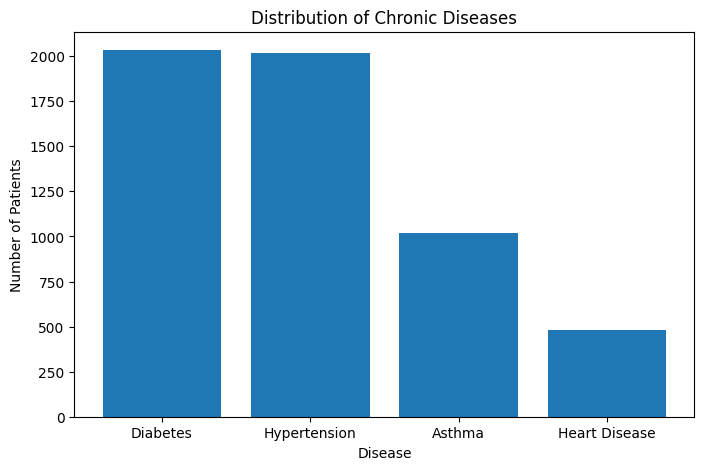

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    disease_distribution.index,
    disease_distribution.values
)

plt.title("Distribution of Chronic Diseases")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")

plt.show()

# What percentage of patients have an insurance ?

In [16]:
insurance_percentage = df["insurance"].value_counts(normalize = True)*100

insurance_percentage

insurance
Yes    60.08
No     39.92
Name: proportion, dtype: float64

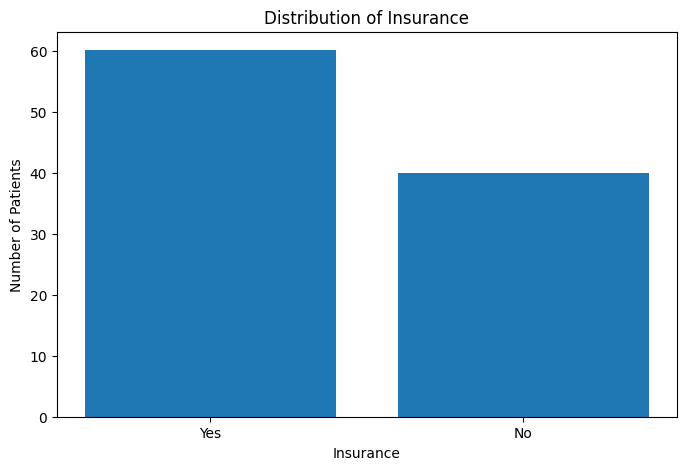

In [17]:
plt.figure(figsize=(8,5))

plt.bar(
    insurance_percentage.index,
    insurance_percentage.values
)

plt.title("Distribution of Insurance")
plt.xlabel("Insurance")
plt.ylabel("Number of Patients")

plt.show()

60% of total patients are insured whereas 40% aren't.

The Hospital Management can use this opportunity to get partnership with and insurance company for providing payment assitance to patients with no insurance  

# Which department has the highest count of patients in the hopital

In [19]:
department_load = df["department"].value_counts()

department_load

department
Cardiology          1075
Ophthalmology       1044
Pulmonology         1028
Gastroenterology    1027
Gynecology          1013
Dermatology          983
Orthopedics          982
Dental               968
General Medicine     962
Neurology            918
Name: count, dtype: int64

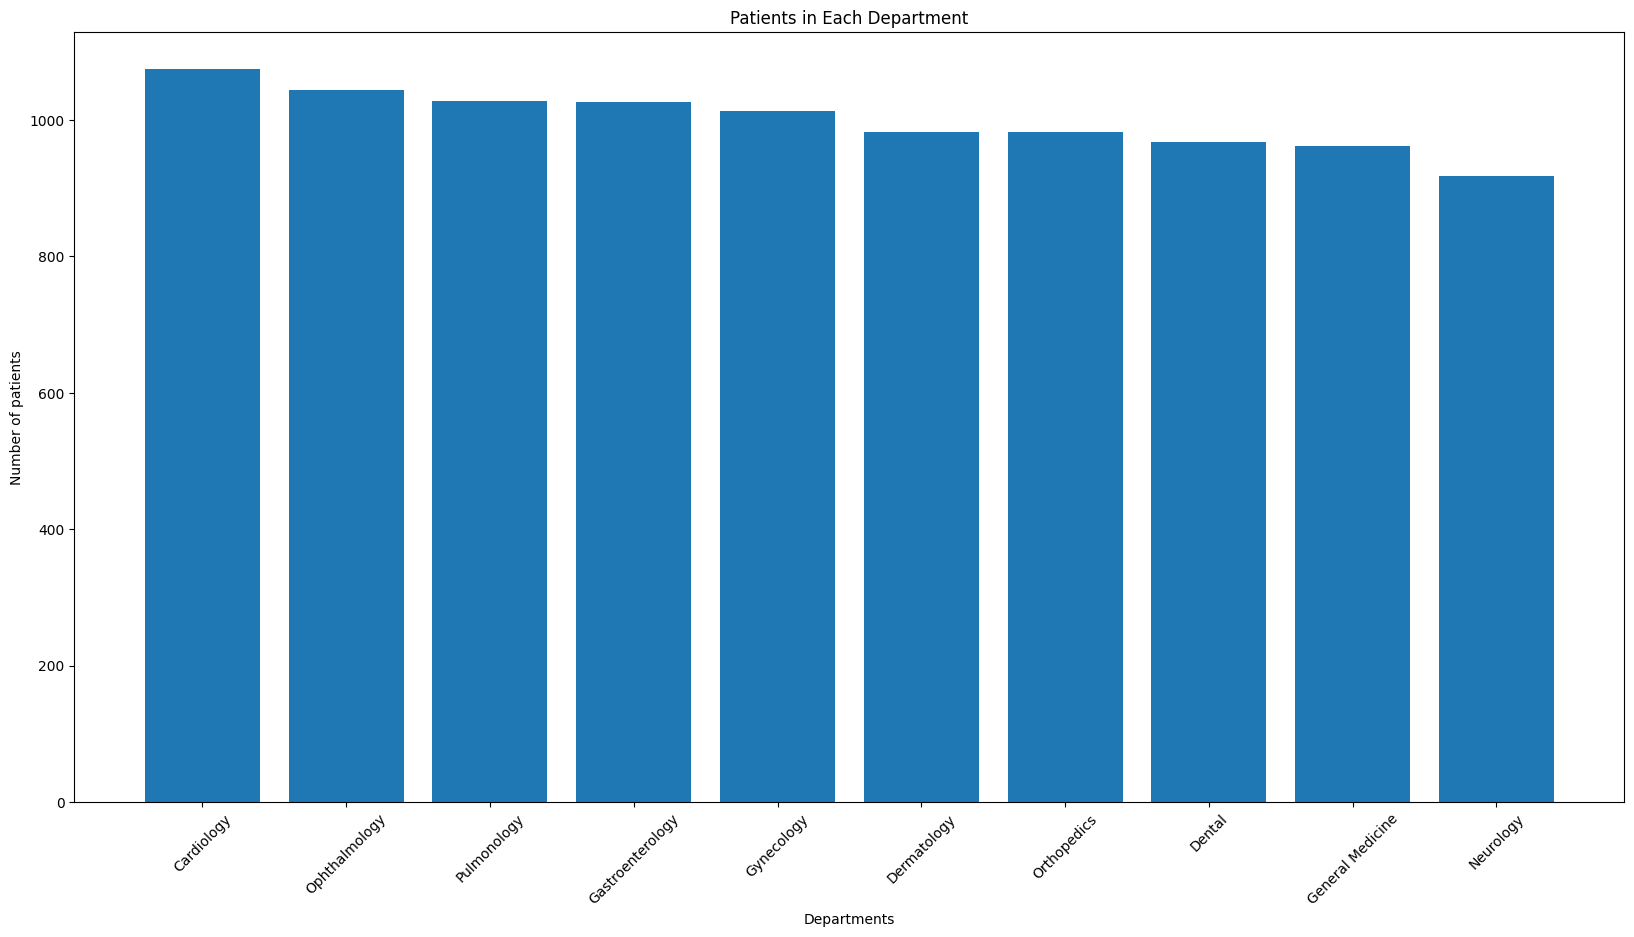

In [26]:
plt.figure(figsize=(20,10))

plt.bar(
    department_load.index,
    department_load.values
)

plt.title('Patients in Each Department')
plt.xlabel('Departments')
plt.ylabel('Number of patients')

plt.xticks(rotation=45)

plt.show()

We can clearly see that Cardiology is most busiest department and neurology is least .
Incase of emergency we can take help by using resources from other departments like neurology and generic medicine if possible.
This also help us to determine that we need to focus/invest little extra in cardiology as compared to others to reduce workload of staff and doctors .

# Which appintment type is mostly used of patients 

In [28]:
appointment_type = df["appointment_type"].value_counts()

appointment_type

appointment_type
Scheduled    5433
Walk-in      3081
Emergency    1486
Name: count, dtype: int64

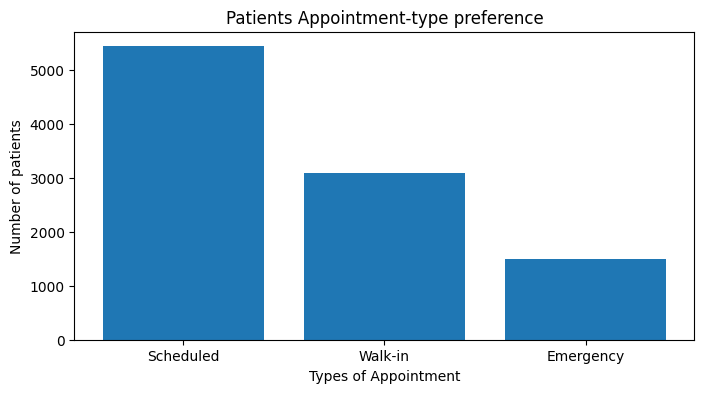

In [107]:
plt.figure(figsize=(8,4))

plt.bar(
    appointment_type.index,
    appointment_type.values
)

plt.title("Patients Appointment-type preference")
plt.xlabel("Types of Appointment")
plt.ylabel("Number of patients")

plt.savefig("images/05_Patient_Appointment_Preference.png", dpi=300, bbox_inches="tight")

plt.show()

Most of the patients prefer Scheduled appointment type, due to which we can use various methods to increase the efficiency of the Hospital and provide better satisfaction to patients knowing everthing in advance help to improve operations better. 

# which day of week gets highest patients appointment?

In [33]:
days_count = df["appointment_day"].value_counts()

days_count

appointment_day
Saturday     1724
Friday       1695
Monday       1669
Thursday     1664
Wednesday    1652
Tuesday      1596
Name: count, dtype: int64

Text(0, 0.5, 'Number of Patients')

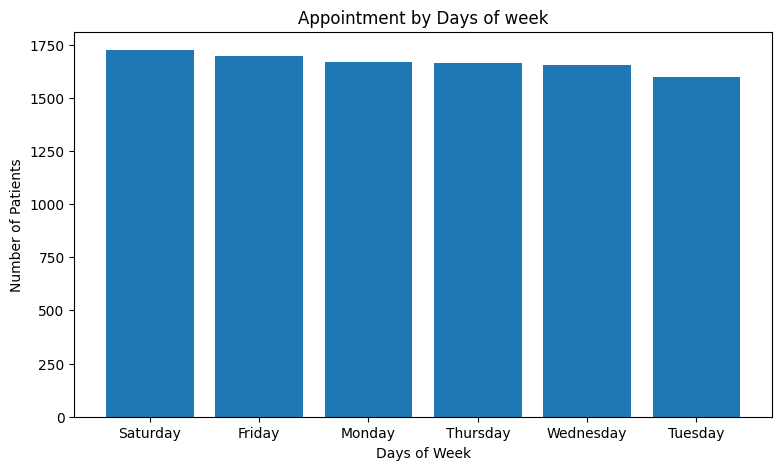

In [35]:
plt.figure(figsize=[9,5])

plt.bar(
    days_count.index,
    days_count.values
)

plt.title("Appointment by Days of week")
plt.xlabel("Days of Week")
plt.ylabel("Number of Patients")

Most of the patients take appointment on weekend saturday followed by friday then 1st day of week Monday.
To handle the stress of saturday we can make hospital operational 7 days a week but with fixed working hours for Normal patients or can arrange fixed slots of appointment on sundays only.

# Months with highest number of patients

In [37]:
month_counts = df['appointment_month'].value_counts()

month_counts

appointment_month
February     878
August       872
July         860
April        856
June         854
December     840
October      826
May          819
March        818
January      813
November     792
September    772
Name: count, dtype: int64

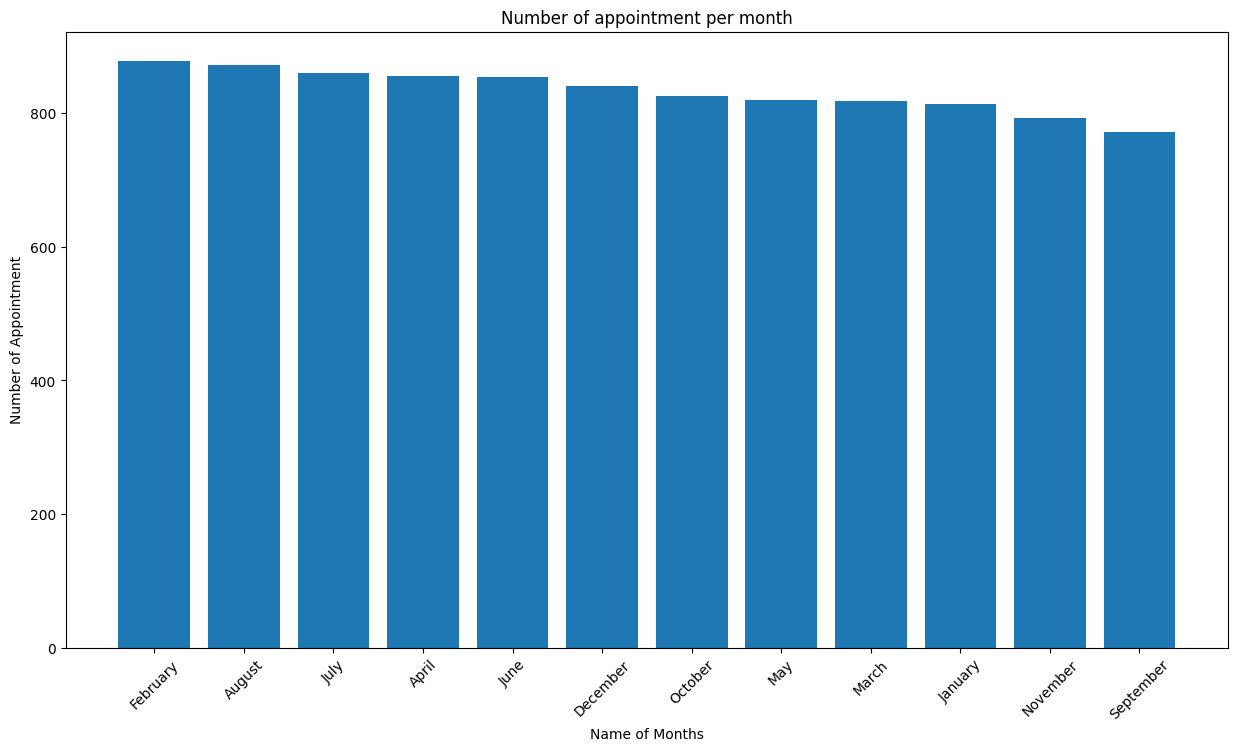

In [39]:
plt.figure(figsize=(15,8))

plt.bar(
    month_counts.index,
    month_counts.values
)

plt.title("Number of appointment per month")
plt.xlabel("Name of Months")
plt.ylabel("Number of Appointment")

plt.xticks(rotation=45)
    
plt.show()

February is the most busiet month followed by August .
Janurary is less busy month then we can use the spare time to manage inventory , resource for february . 

# Do patients with long waiting times have lower satisfaction scores?

In [40]:
waiting_satisfaction = (
    df.groupby("long_wait_flag")["patient_satisfaction_score"]
      .mean()
)

waiting_satisfaction

long_wait_flag
No     9.988954
Yes    9.181486
Name: patient_satisfaction_score, dtype: float64

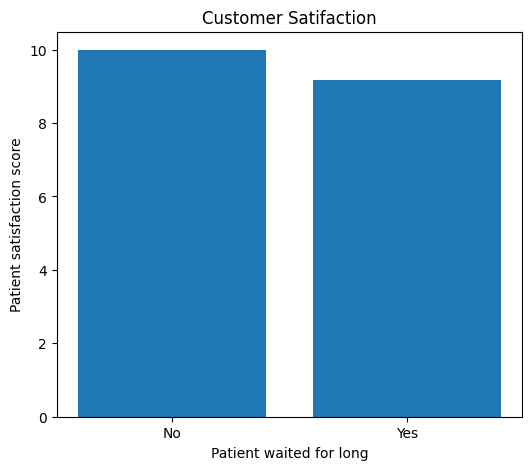

In [42]:
plt.figure(figsize=(6,5))

plt.bar(
    waiting_satisfaction.index,
    waiting_satisfaction.values
)

plt.title("Customer Satifaction")
plt.xlabel("Patient waited for long")
plt.ylabel("Patient Average satisfaction score")

plt.show()

Longer waiting time (more than 30 minutes) results in low patient satisfaction score i.e. 9.18.
Hospital should improve their operations and increase efforts to increase customer satisfaction


# which depatment has highest average waiting time?

In [45]:
average_waiting_time = (
    df.groupby("department")["waiting_time_minutes"].mean()
)

average_waiting_time 

department
Cardiology          18.860465
Dental              24.896694
Dermatology         24.111902
Gastroenterology    24.000000
General Medicine    30.895010
Gynecology          19.187562
Neurology           30.251634
Ophthalmology       25.664751
Orthopedics         24.523422
Pulmonology         30.650778
Name: waiting_time_minutes, dtype: float64

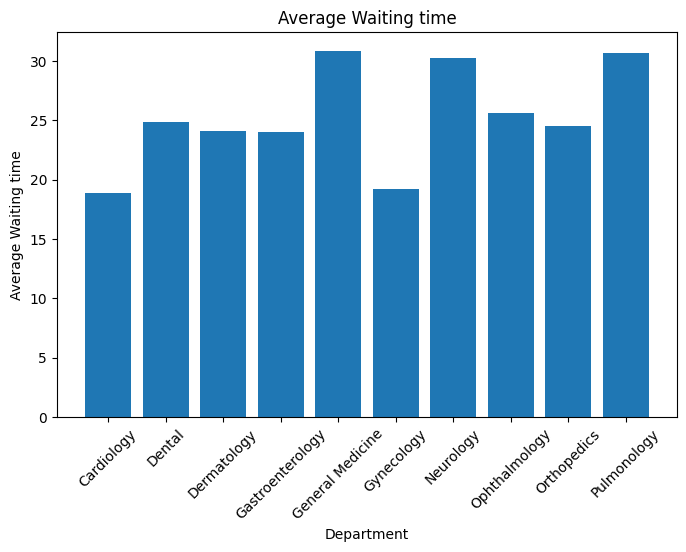

In [108]:
plt.figure(figsize=(8,5))

plt.bar(
    average_waiting_time.index,
    average_waiting_time.values
)

plt.title("Average Waiting time")
plt.xlabel("Department")
plt.ylabel("Average Waiting time")

plt.xticks(rotation = 45)

plt.savefig("images/06_Waiting_time_per_department.png", dpi=300, bbox_inches="tight")

plt.show()

pulmonology and Gastroenterology has the highest average waiting time. Proper management is needed to reduce the waiting time and increase patient satisfaction.

# Section 4 Emergency and Severity 


# Do emergency patients wait less than normal patients ?


In [50]:
waiting_time = (
    df.groupby("emergency_case")["waiting_time_minutes"].mean()
)

waiting_time

emergency_case
0    25.112873
1    25.725437
Name: waiting_time_minutes, dtype: float64

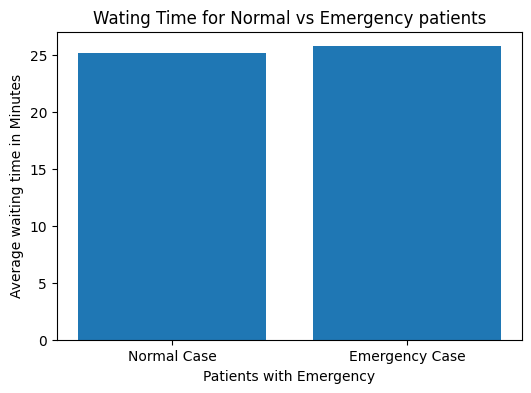

In [55]:
plt.figure(figsize=(6,4))

plt.bar(
    waiting_time.index,
    waiting_time.values
)

plt.xticks(ticks=[0, 1], labels=["Normal Case", "Emergency Case"])

plt.title("Wating Time for Normal vs Emergency patients")
plt.ylabel("Average waiting time in Minutes")
plt.xlabel("Patients with Emergency")

plt.show()

The patients with emergency case has to wait longer than the normal patients.
This is major issue in the hsopital management system and operation .
Emergency cases should be prioritize in any manner . 
This will heavily impact the customer satisfaction and hospital reputation.
NEED TO IMPLEMENT NEW RULES OR MAKE A SPECIAL EMERGENCY WARD TO SERVE THEM IN PRIORITY

# Do Severe patients have high medical bills

In [57]:
bill = (
    df.groupby("severity_level")["total_bill"].mean()
)

bill

severity_level
High      18589.734987
Low        1353.458686
Medium     5012.228107
Name: total_bill, dtype: float64

plt.figure(figsize=(6,4))

plt.bar(
    bill.index,
    bill.values
)

plt.title("Average bill based on Severity level")
plt.xlabel("Severity level")
plt.ylabel("Average bill amount")

plt.show()

Yes Severity level highly affect the total bill amount for patients more severe the patients the bills skyrocket.
We can offer partnerships to insurance providers to help people with smooth and easy bill clearnace assitance.

# Which department handles the most emergency cases?

In [61]:
emergency_cases = (
    df.groupby("department")["emergency_case"].sum()
)

emergency_cases

department
Cardiology          167
Dental              151
Dermatology         129
Gastroenterology    148
General Medicine    138
Gynecology          153
Neurology           146
Ophthalmology       163
Orthopedics         141
Pulmonology         150
Name: emergency_case, dtype: int64

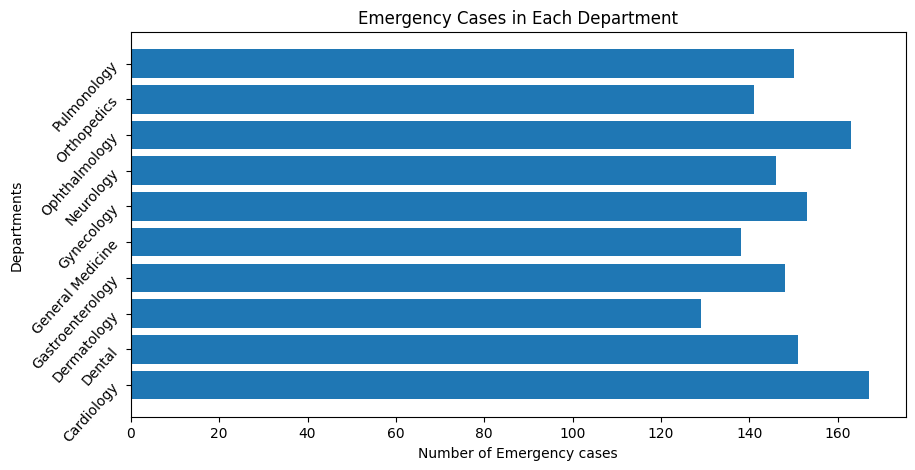

In [111]:
plt.figure(figsize=(10,5))

plt.barh(
    emergency_cases.index,
    emergency_cases.values
)

plt.title("Emergency Cases in Each Department")
plt.xlabel("Number of Emergency cases")
plt.ylabel("Departments")

plt.yticks(rotation=48)

plt.savefig("images/04_Department_Emergency_cases.png", dpi=300, bbox_inches="tight")

plt.show()


Cardiology has the highest number of emergency cases followed by opthalmology.
Emergency cases have high average waiting time than normal patients and in departments like CARDIOLOGY can cause many casualitites .
The emergency management system and cardiology department need most attention and extra staff than others as it is also most busiest department

# Does severity level affect patient satisfaction?

In [66]:
p_satisfaction = (
    df.groupby("severity_level")["patient_satisfaction_score"].mean()
)

p_satisfaction

severity_level
High      10.000000
Low        9.244540
Medium     9.881151
Name: patient_satisfaction_score, dtype: float64

The severity dont have very high impact but yes its slightly affects patients satisfaction score .

# Section 5

# Experience vs Fees of doctors


In [67]:
experience_fees = (
    df.groupby("doctor_experience_years")["consultation_fee"].mean()
)

experience_fees

doctor_experience_years
1     322.511494
2     338.045198
3     359.887821
4     379.894231
5     399.601140
6     421.201201
7     435.877023
8     469.426866
9     477.466292
10    504.006369
11    514.977011
12    541.311377
13    561.075269
14    581.539216
15    601.135211
16    620.671271
17    639.332308
18    651.577586
19    676.825215
20    691.897590
21    713.280374
22    738.281065
23    763.420561
24    779.747093
25    794.968354
26    819.535032
27    838.065217
28    858.720365
29    876.543689
30    895.489426
Name: consultation_fee, dtype: float64

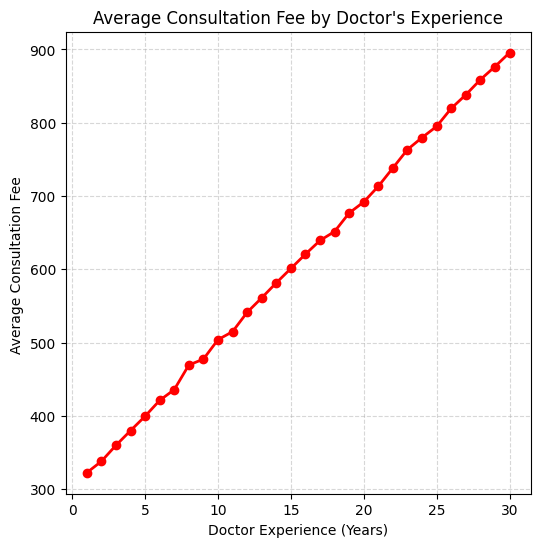

In [109]:
plt.figure(figsize=(6,6))

plt.plot(
    experience_fees.index,   
    experience_fees.values,  
    marker='o',              # Adds dots on the line
    linestyle='-',          # Solid line
    color='red',            # Color of the line
    linewidth=2
)

plt.title("Average Consultation Fee by Doctor's Experience")
plt.xlabel("Doctor Experience (Years)")
plt.ylabel("Average Consultation Fee ")
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig("images/07_experience_fees.png", dpi=300, bbox_inches="tight")

The consulting fees is directly proportional to doctor experience years .
More experience leads to higher consulting fee

# Experience vs Satisfaction


In [71]:
score = (
    df.groupby("doctor_experience_years")["patient_satisfaction_score"].mean()
)

score

doctor_experience_years
1     9.659483
2     9.702825
3     9.661218
4     9.675962
5     9.741026
6     9.721021
7     9.656311
8     9.716418
9     9.689045
10    9.707006
11    9.750862
12    9.694910
13    9.652688
14    9.688235
15    9.682254
16    9.729282
17    9.707077
18    9.698851
19    9.714613
20    9.723795
21    9.666355
22    9.702367
23    9.714019
24    9.740698
25    9.711709
26    9.735987
27    9.698137
28    9.714286
29    9.674434
30    9.721450
Name: patient_satisfaction_score, dtype: float64

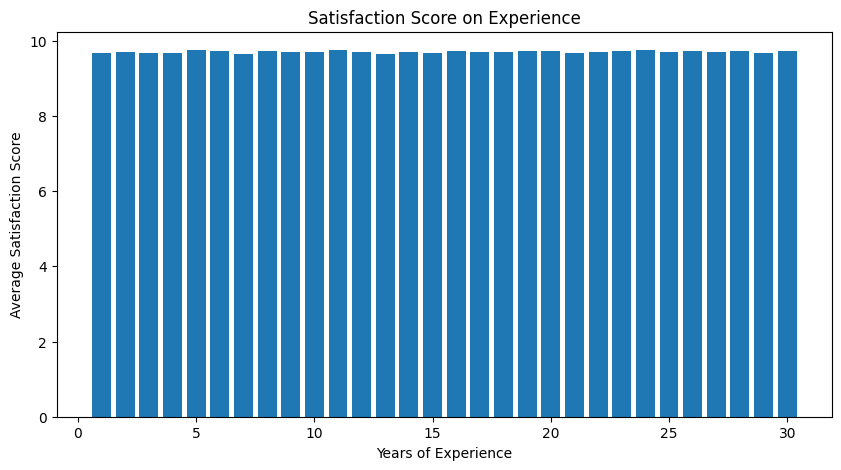

In [74]:
plt.figure(figsize=(10,5))

plt.bar(
    score.index,
    score.values
)           

plt.title("Satisfaction Score on Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Average Satisfaction Score")

plt.show()

There is no such affect of experience on the patient satisfaction score .


# Average experience per department

In [76]:
dept_exp_avg = (
    df.groupby("department")["doctor_experience_years"].mean()
)
dept_exp_avg

department
Cardiology          15.739535
Dental              15.182851
Dermatology         15.380468
Gastroenterology    15.500487
General Medicine    15.242204
Gynecology          15.356367
Neurology           15.459695
Ophthalmology       15.426245
Orthopedics         15.203666
Pulmonology         15.456226
Name: doctor_experience_years, dtype: float64

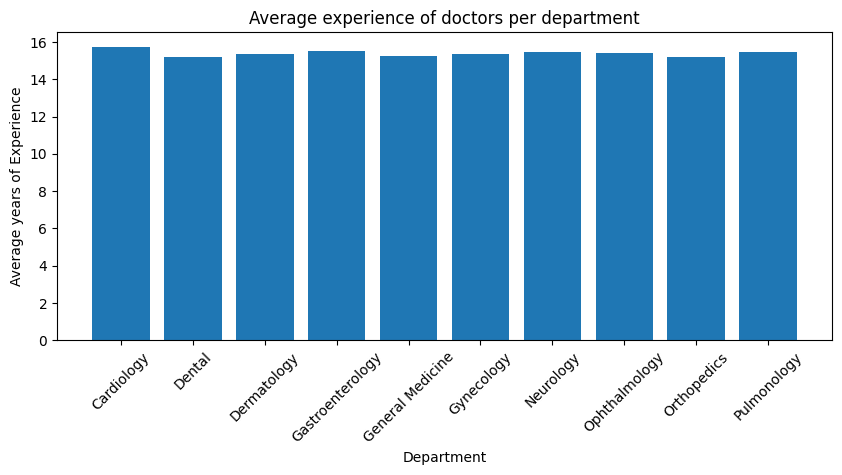

In [77]:
plt.figure(figsize=(10,4))

plt.bar(
    dept_exp_avg.index,
    dept_exp_avg.values
)

plt.title("Average experience of doctors per department")
plt.xlabel("Department")
plt.ylabel("Average years of Experience")

plt.xticks(rotation = 45)

plt.show()

 The overall average experience ranges between 15 to 16 for every department

# Emergency case vs experience of doctors

In [84]:
case_doctors = (
    df.groupby("doctor_experience_years")["emergency_case"].sum()
)

case_doctors

doctor_experience_years
1     39
2     53
3     53
4     34
5     43
6     59
7     43
8     54
9     55
10    45
11    56
12    60
13    46
14    42
15    63
16    54
17    49
18    49
19    55
20    58
21    48
22    49
23    41
24    49
25    59
26    55
27    47
28    47
29    40
30    41
Name: emergency_case, dtype: int64

Doctor with 15 years experience has highest emergency cases.  

# Revenue by Department

In [86]:
revenue = (
    df.groupby("department")["total_bill"].sum()
    
)

revenue

department
Cardiology          12345772.1
Dental               8405963.0
Dermatology          8284182.3
Gastroenterology     8858439.6
General Medicine     4299978.4
Gynecology          11533350.5
Neurology            4397969.1
Ophthalmology        8065695.1
Orthopedics          8114204.7
Pulmonology          4512125.2
Name: total_bill, dtype: float64

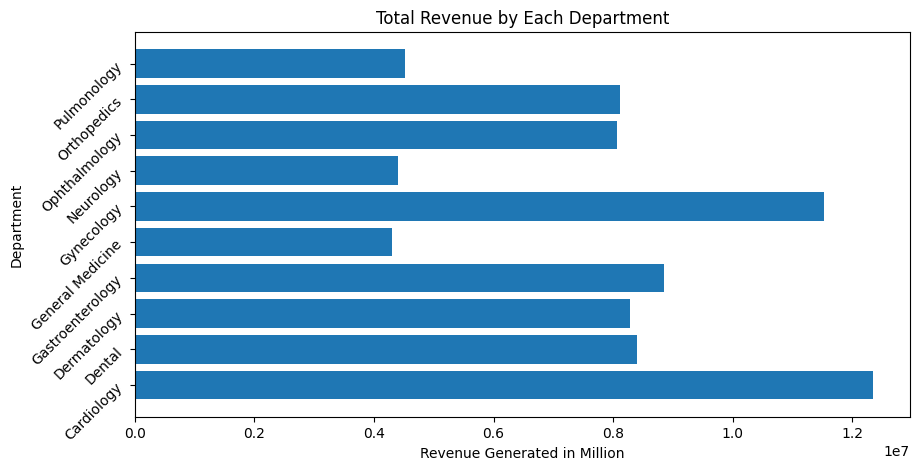

In [110]:
plt.figure(figsize=(10,5))

plt.barh(
    revenue.index,
    revenue.values
)

plt.title("Total Revenue by Each Department")
plt.ylabel("Department")
plt.xlabel("Revenue Generated in Million")

plt.yticks(rotation = 45)

plt.savefig("images/08_Revenue_Share_In_departments.png", dpi=300, bbox_inches="tight")

plt.show()

Cardiology department has highest contribution in the revenue followed by gynecology .
General Medicine and Neurology has lowest contribution in revenue 

# insurance vs Bills 

In [90]:
hospital_bill = (
    df.groupby("insurance")["total_bill"].sum()
)

hospital_bill 

insurance
No     38884269.0
Yes    39933411.0
Name: total_bill, dtype: float64

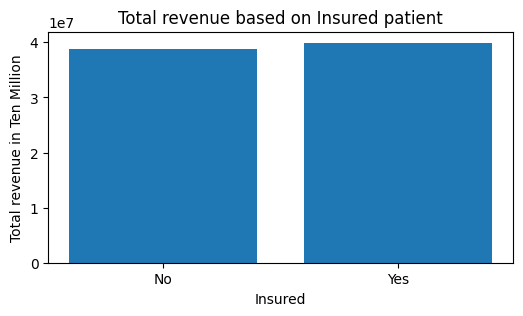

In [93]:
plt.figure(figsize=(6,3))

plt.bar(
    hospital_bill.index,
    hospital_bill.values
)

plt.title("Total revenue based on Insured patient")
plt.xlabel("Insured")
plt.ylabel("Total revenue in Ten Million")

plt.show()

There is little difference in Insured patient revenue to Non Insured .
Therefore the hospital revenue is not highly affected by insurance of patients 

# Age group vs Bill

In [96]:
group_bill = (
    df.groupby("age_group")["total_bill"].mean()
)
group_bill

age_group
Child          8067.379206
Middle Aged    7782.311631
Senior         7880.283242
Teen           7796.376431
Young Adult    8025.279016
Name: total_bill, dtype: float64

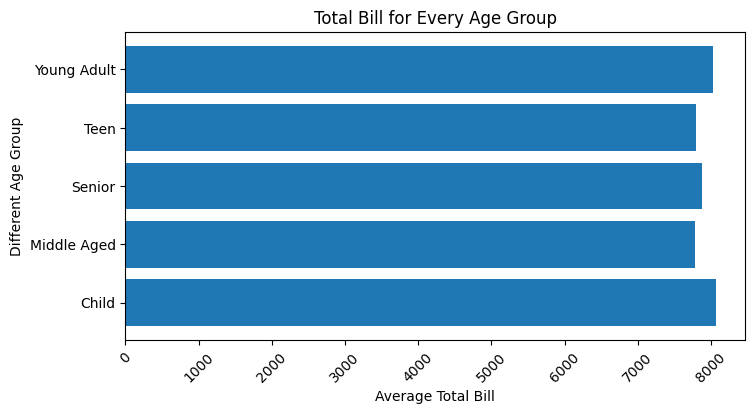

In [98]:
plt.figure(figsize=(8,4))

plt.barh(
    group_bill.index,
    group_bill.values
)

plt.title("Total Bill for Every Age Group")
plt.ylabel("Different Age Group")
plt.xlabel("Average Total Bill")

plt.xticks(rotation = 45)

plt.show()